(973, 15)
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64
Experience_Level
2    406
1    376
3    191
Name: count, dtype: int64


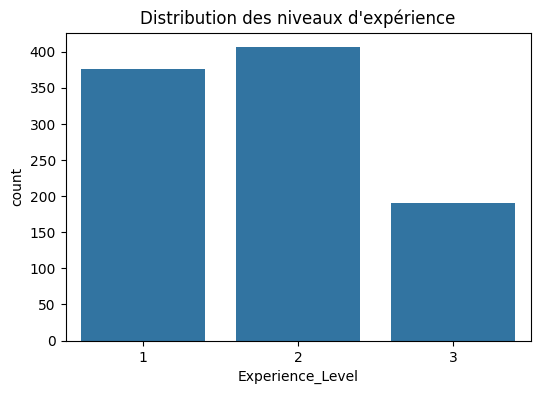

In [12]:
import seaborn as sns, pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv('../data/gym_members_exercise_tracking.csv')

print(df.shape)
print(df.isnull().sum())
print(df['Experience_Level'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Experience_Level')
plt.title("Distribution des niveaux d'expérience")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = df.dropna()

df_encoded = pd.get_dummies(df, columns=['Gender', 'Workout_Type'], drop_first=True)

X = df_encoded.drop(columns=['Experience_Level'])
y = df_encoded['Experience_Level']

le = LabelEncoder()
y = le.fit_transform(y)
print('Classes:', le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Classes: [1 2 3]
Train: 778 | Test: 195


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import json

# Simple logging instead of mlflow
experiment_results = []

modeles = {
    "Arbre": DecisionTreeClassifier(random_state=42),
    "Foret": RandomForestClassifier(random_state=42)
}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    score = accuracy_score(y_test, modele.predict(X_test))
    print(f"{nom} Accuracy : {score:.3f}")

param_grid = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
clf = RandomForestClassifier(random_state=42, n_jobs=-1)

print("GridSearch en cours...")
grid = GridSearchCV(clf, param_grid, cv=2, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_clf = grid.best_estimator_

# Log results
print("\n✓ GridSearch terminé!")
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score :", f"{grid.best_score_:.3f}")

experiment_results.append({
    "run": "GridSearch_RF",
    "params": grid.best_params_,
    "accuracy": float(grid.best_score_)
})

print("\nRésultats sauvegardés")

Arbre Accuracy : 0.851
Foret Accuracy : 0.908
GridSearch en cours...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

✓ GridSearch terminé!
Meilleurs paramètres : {'max_depth': 10, 'n_estimators': 100}
Meilleur score : 0.875

Résultats sauvegardés


              precision    recall  f1-score   support

           1       0.93      0.85      0.89        75
           2       0.88      0.94      0.91        82
           3       1.00      1.00      1.00        38

    accuracy                           0.92       195
   macro avg       0.93      0.93      0.93       195
weighted avg       0.92      0.92      0.92       195



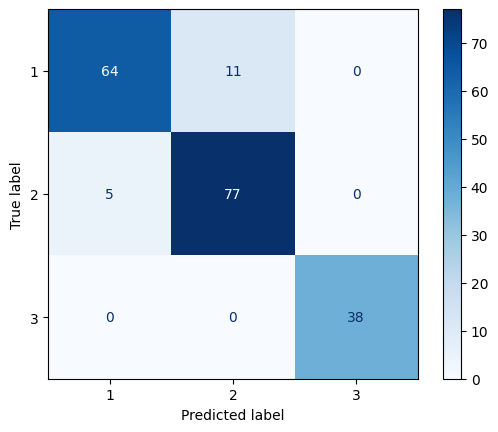

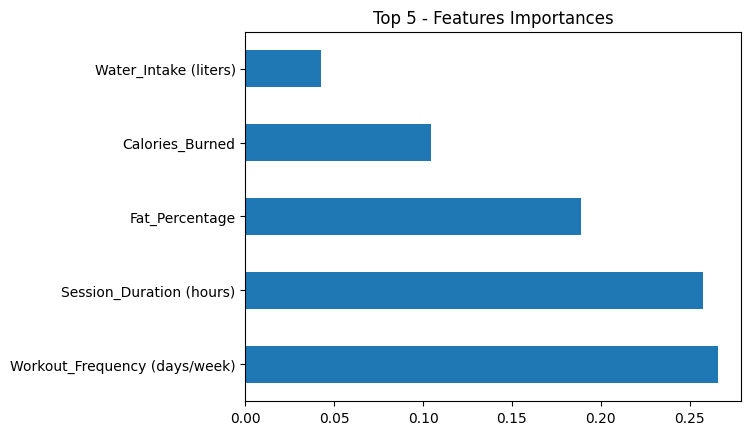

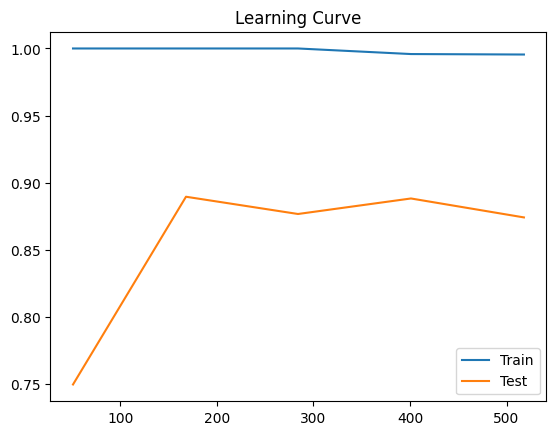

In [15]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve
import numpy as np

y_pred = best_clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.show()

pd.Series(best_clf.feature_importances_, index=X.columns).nlargest(5).plot(kind='barh')
plt.title("Top 5 - Features Importances")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(best_clf, X_train, y_train, cv=3)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Test')
plt.legend()
plt.title("Learning Curve")
plt.show()

In [16]:
import joblib, os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_clf, '../models/model.pkl')
joblib.dump(le, '../models/encoder.pkl')

print('models/model.pkl et models/encoder.pkl créés')

models/model.pkl et models/encoder.pkl créés
